# Bank Fragility — Exploratory Data Analysis
Loads and explores the parquet files in `_data/`.

In [48]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path('../.env'))

DATA_DIR   = Path('../_data')
OUTPUT_DIR = Path('../_output')

sys.path.insert(0, str(Path('../scripts').resolve()))
from pull_gsib_banks import pull_gsib_list

gsib     = pd.read_parquet(DATA_DIR / 'gsib_list.parquet')
mbs      = pd.read_parquet(DATA_DIR / 'mbs_etfs.parquet')
treasury = pd.read_parquet(DATA_DIR / 'treasury_yields.parquet')
panel    = pd.read_parquet(DATA_DIR / 'bank_panel_12312025.parquet')
shocks   = pd.read_parquet(DATA_DIR / 'market_shocks.parquet')

SMALL_CUTOFF = 1.384e6
gsib_ids = set(gsib['rssd_id_call'])

panel['bank_category'] = 'Small'
panel.loc[panel['Total Asset'] >= SMALL_CUTOFF, 'bank_category'] = 'Large'
panel.loc[panel['rssd_id_call'].isin(gsib_ids), 'bank_category'] = 'GSIB'

start_date = pd.to_datetime(os.getenv('MARKET_START_DATE', '2020-01-01'))
end_date   = pd.to_datetime(os.getenv('MARKET_END_DATE',   '2023-12-31'))

print('All data loaded.')

All data loaded.


## 1. GSIB List

In [49]:
print('Shape:', gsib.shape)
print('Dtypes:\n', gsib.dtypes)
gsib.head(10)

Shape: (37, 2)
Dtypes:
 rssd_id_call    int32
is_gsib         int64
dtype: object


,rssd_id_call,is_gsib
0,934329,1
1,488318,1
2,212465,1
3,449038,1
4,476810,1
5,3382547,1
6,852218,1
7,651448,1
8,480228,1
9,1443266,1


In [50]:
print('Missing values:\n', gsib.isna().sum())
print('\nUnique banks:', gsib['rssd_id_call'].nunique())

Missing values:
 rssd_id_call    0
is_gsib         0
dtype: int64

Unique banks: 37


## 2. MBS ETFs

In [51]:
print('Shape:', mbs.shape)
print('Dtypes:\n', mbs.dtypes)
mbs.head()

Shape: (3552, 5)
Dtypes:
 date        datetime64[ns]
rmbs_px            float64
cmbs_px            float64
rmbs_ret           float64
cmbs_ret           float64
dtype: object


,date,rmbs_px,cmbs_px,rmbs_ret,cmbs_ret
0,2012-02-16,17.901064,35.036316,NaN,NaN
1,2012-02-17,17.927101,34.870251,0.001455,-0.004740
2,2012-02-21,17.894552,34.780304,-0.001816,-0.002579
3,2012-02-22,17.959661,34.593510,0.003638,-0.005371
4,2012-02-23,17.901064,34.593510,-0.003263,0.000000


In [52]:
print('Date range:', mbs['date'].min().date(), 'to', mbs['date'].max().date())
print('\nMissing values:\n', mbs.isna().sum())
print('\nSummary stats:')
mbs.describe()

Date range: 2012-02-16 to 2026-04-02

Missing values:
 date        0
rmbs_px     0
cmbs_px     0
rmbs_ret    1
cmbs_ret    1
dtype: int64

Summary stats:


,date,rmbs_px,cmbs_px,rmbs_ret,cmbs_ret
count,3552,3552.000000,3552.000000,3551.000000,3551.000000
mean,2019-03-09 15:57:09.729729792,19.974007,41.541433,0.000072,0.000099
min,2012-02-16 00:00:00,17.479326,34.593510,-0.116755,-0.065884
25%,2015-08-27 18:00:00,19.096314,38.427753,-0.001374,-0.001708
50%,2019-03-11 12:00:00,19.778141,40.736416,0.000000,0.000000
75%,2022-09-16 18:00:00,21.080786,44.986781,0.001509,0.001771
max,2026-04-02 00:00:00,22.679871,49.591946,0.126610,0.037525
std,NaN,1.333782,3.781217,0.004195,0.003466


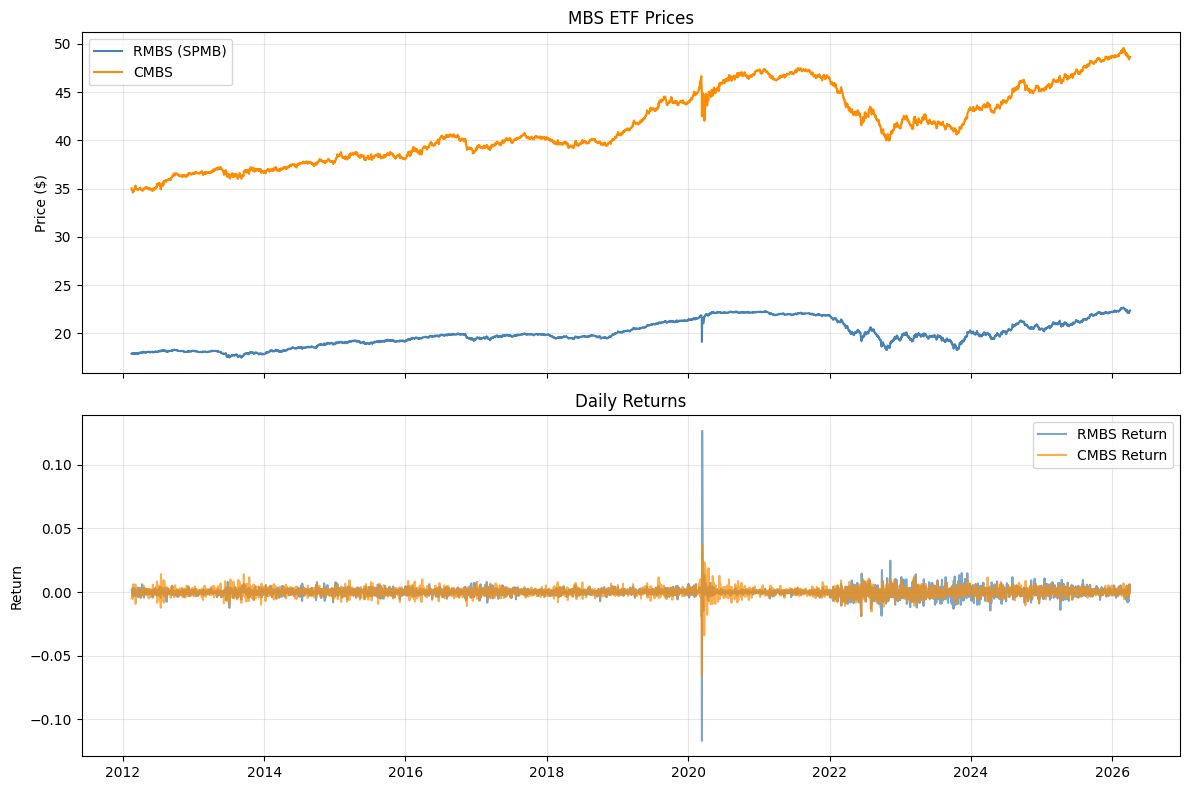

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(mbs['date'], mbs['rmbs_px'], label='RMBS (SPMB)', color='steelblue')
axes[0].plot(mbs['date'], mbs['cmbs_px'], label='CMBS', color='darkorange')
axes[0].set_title('MBS ETF Prices')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(mbs['date'], mbs['rmbs_ret'], label='RMBS Return', color='steelblue', alpha=0.7)
axes[1].plot(mbs['date'], mbs['cmbs_ret'], label='CMBS Return', color='darkorange', alpha=0.7)
axes[1].set_title('Daily Returns')
axes[1].set_ylabel('Return')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Treasury Yields

In [54]:
print('Shape:', treasury.shape)
print('Dtypes:\n', treasury.dtypes)
treasury.head()

Shape: (16046, 7)
Dtypes:
 date     datetime64[ns]
dgs1            float64
dgs3            float64
dgs5            float64
dgs10           float64
dgs20           float64
dgs30           float64
dtype: object


,date,dgs1,dgs3,dgs5,dgs10,dgs20,dgs30
0,1962-01-02,3.22,3.70,3.88,4.06,4.07,NaN
1,1962-01-03,3.24,3.70,3.87,4.03,4.07,NaN
2,1962-01-04,3.24,3.69,3.86,3.99,4.06,NaN
3,1962-01-05,3.26,3.71,3.89,4.02,4.07,NaN
4,1962-01-08,3.31,3.71,3.91,4.03,4.08,NaN


In [55]:
print('Date range:', treasury['date'].min().date(), 'to', treasury['date'].max().date())
print('\nMissing values:\n', treasury.isna().sum())
print('\nSummary stats:')
treasury.describe()

Date range: 1962-01-02 to 2026-04-01

Missing values:
 date        0
dgs1        0
dgs3        0
dgs5        0
dgs10       0
dgs20    1689
dgs30    3770
dtype: int64

Summary stats:


,date,dgs1,dgs3,dgs5,dgs10,dgs20,dgs30
count,16046,16046.000000,16046.000000,16046.000000,16046.000000,14357.000000,12276.000000
mean,1994-02-24 01:28:12.982674816,4.878951,5.245813,5.489404,5.814051,5.852714,6.165085
min,1962-01-02 00:00:00,0.040000,0.100000,0.190000,0.520000,0.870000,0.990000
25%,1978-02-03 18:00:00,2.310000,2.850000,3.290000,3.890000,4.060000,3.900000
50%,1994-03-05 12:00:00,4.910000,5.010000,5.235000,5.430000,5.230000,5.460000
75%,2010-03-17 18:00:00,6.660000,7.180000,7.380000,7.540000,7.250000,8.060000
max,2026-04-01 00:00:00,17.310000,16.590000,16.270000,15.840000,15.780000,15.210000
std,NaN,3.356635,3.251755,3.130547,2.937256,2.836605,2.983589


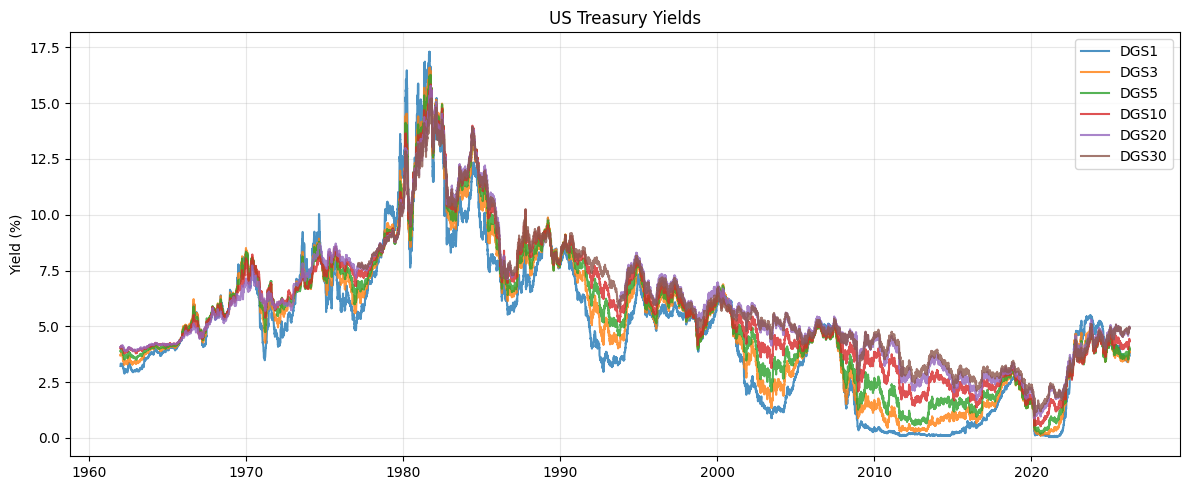

In [56]:
yield_cols = ['dgs1', 'dgs3', 'dgs5', 'dgs10', 'dgs20', 'dgs30']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

plt.figure(figsize=(12, 5))
for col, color in zip(yield_cols, colors):
    plt.plot(treasury['date'], treasury[col], label=col.upper(), color=color, alpha=0.8)

plt.title('US Treasury Yields')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

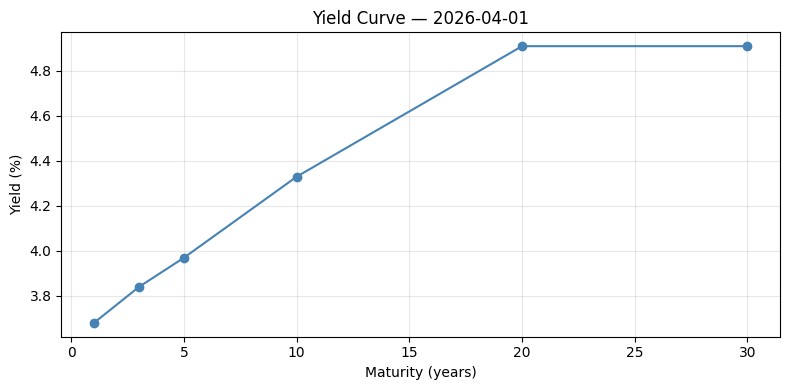

In [57]:
latest = treasury.dropna(subset=yield_cols, how='any').iloc[-1]
maturities = [1, 3, 5, 10, 20, 30]

plt.figure(figsize=(8, 4))
plt.plot(maturities, [latest[c] for c in yield_cols], marker='o', color='steelblue')
plt.title(f"Yield Curve — {latest['date'].date()}")
plt.xlabel('Maturity (years)')
plt.ylabel('Yield (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. FFIEC Bank Panel

In [58]:
print('Shape:', panel.shape)
print('Columns:', panel.columns.tolist())
panel.head()

Shape: (4394, 67)
Columns: ['rssd_id_call', 'Total Asset', 'cash', 'security_total', 'security_treasury', 'security_rmbs', 'security_cmbs', 'security_abs', 'security_other', 'Total_Loan', 'Real_Estate_Loan', 'Residential_Mortgage', 'Commercial_Mortgage', 'Other_Real_Estate_Mortgage', 'Agri_Loan', 'Comm_Indu_Loan', 'Consumer_Loan', 'Non_Rep_Loan', 'Fed_Fund_Sold', 'Reverse_Repo', 'rmbs_lt1y', 'rmbs_1_3y', 'rmbs_3_5y', 'rmbs_5_10y', 'rmbs_10_15y', 'rmbs_15plus', 'treasury_lt1y', 'other_assets_lt1y', 'res_mtg_lt1y', 'other_loan_lt1y', 'treasury_1_3y', 'other_assets_1_3y', 'res_mtg_1_3y', 'other_loan_1_3y', 'treasury_3_5y', 'other_assets_3_5y', 'res_mtg_3_5y', 'other_loan_3_5y', 'treasury_5_10y', 'other_assets_5_10y', 'res_mtg_5_10y', 'other_loan_5_10y', 'treasury_10_15y', 'other_assets_10_15y', 'res_mtg_10_15y', 'other_loan_10_15y', 'treasury_15plus', 'other_assets_15plus', 'res_mtg_15plus', 'other_loan_15plus', 'Total Liability', 'Domestic Deposit', 'Insured Deposit', 'Uninsured Deposit'

,rssd_id_call,Total Asset,cash,security_total,security_treasury,security_rmbs,security_cmbs,security_abs,security_other,Total_Loan,...,Foreign Deposit,Fed Fund Purchase,Repo,Other Liability,Total Equity,Common Stock,Preferred Stock,Retained Earning,report_date,bank_category
0,37,86116.0,17422.0,47217.0,0.0,0.0,0.0,0.0,0.0,19485.0,...,NaN,0,0.0,127.0,13639.0,1200.0,0.0,12897.0,12312025,Small
1,242,56044.0,3138.0,18513.0,3118.0,0.0,0.0,0.0,0.0,30386.0,...,NaN,0,0.0,84.0,5282.0,120.0,0.0,6106.0,12312025,Small
2,279,428509.0,9370.0,76636.0,0.0,0.0,0.0,0.0,0.0,306644.0,...,NaN,0,0.0,2560.0,48665.0,1.0,0.0,34475.0,12312025,Small
3,354,123554.0,4170.0,2128.0,501.0,0.0,0.0,0.0,0.0,98393.0,...,NaN,0,0.0,922.0,12729.0,100.0,0.0,-1492.0,12312025,Small
4,457,87633.0,5864.0,493.0,493.0,0.0,0.0,0.0,0.0,79786.0,...,NaN,0,0.0,278.0,8097.0,60.0,0.0,3107.0,12312025,Small


### 4.1 Bank Counts by Category

Bank counts by category:
bank_category
Small    3572
Large     788
GSIB       34
Name: count, dtype: int64


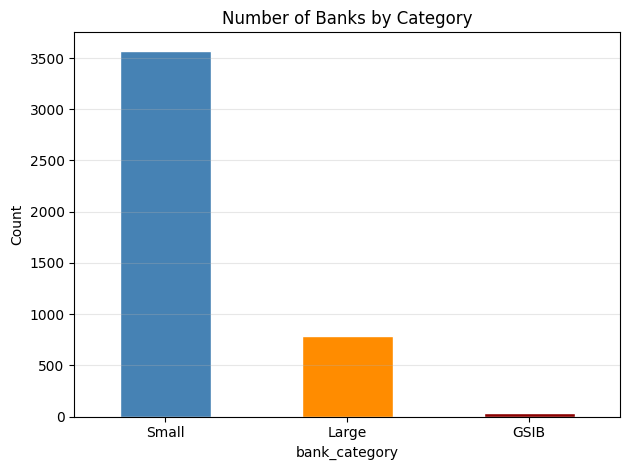

In [59]:
counts = panel['bank_category'].value_counts()
print('Bank counts by category:')
print(counts)

counts.plot(kind='bar', color=['steelblue', 'darkorange', 'darkred'], edgecolor='white')
plt.title('Number of Banks by Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Total Assets Distribution

Total assets across all banks: $25.28T

Assets by category ($T):
bank_category
GSIB     12.50
Large    11.41
Small     1.37
Name: Total Asset, dtype: float64


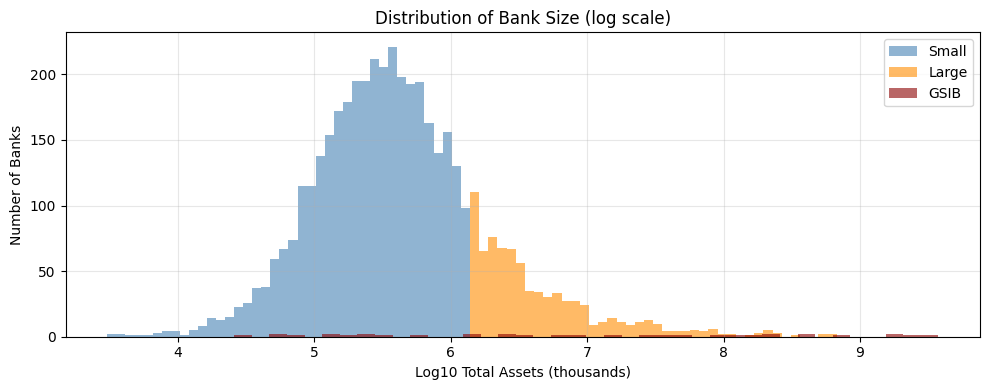

In [60]:
total_assets_T = panel['Total Asset'].sum() / 1e9
print(f'Total assets across all banks: ${total_assets_T:.2f}T')
print(f'\nAssets by category ($T):')
print((panel.groupby('bank_category')['Total Asset'].sum() / 1e9).round(2))

plt.figure(figsize=(10, 4))
for cat, color in zip(['Small', 'Large', 'GSIB'], ['steelblue', 'darkorange', 'darkred']):
    subset = panel[panel['bank_category'] == cat]['Total Asset'].dropna()
    plt.hist(np.log10(subset[subset > 0]), bins=40, alpha=0.6, label=cat, color=color)

plt.xlabel('Log10 Total Assets (thousands)')
plt.ylabel('Number of Banks')
plt.title('Distribution of Bank Size (log scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Asset Composition

Asset composition (% of total assets):
Cash              10.2
Securities        21.7
Total Loan        53.3
Fed Funds Sold     0.1
Reverse Repo       2.7
dtype: float64


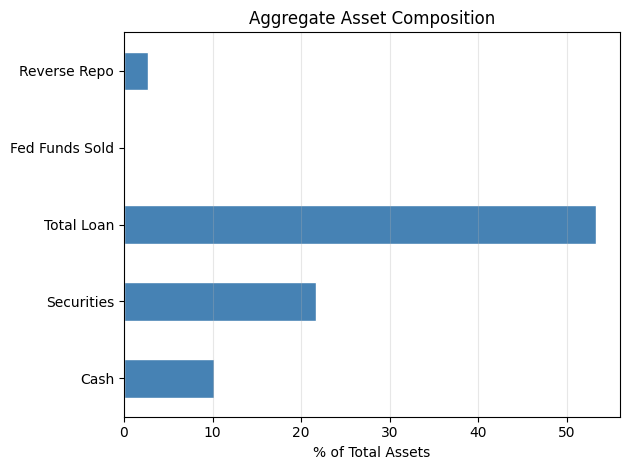

In [61]:
asset_cols = {
    'Cash': 'cash',
    'Securities': 'security_total',
    'Total Loan': 'Total_Loan',
    'Fed Funds Sold': 'Fed_Fund_Sold',
    'Reverse Repo': 'Reverse_Repo',
}

agg = {label: panel[col].sum() for label, col in asset_cols.items() if col in panel.columns}
agg_pct = (pd.Series(agg) / panel['Total Asset'].sum() * 100).round(1)

print('Asset composition (% of total assets):')
print(agg_pct)

agg_pct.plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('% of Total Assets')
plt.title('Aggregate Asset Composition')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 Securities Breakdown

Securities as % of total assets:
Treasury    6.22
RMBS        7.52
CMBS        1.09
ABS         0.25
Other       1.32
dtype: float64


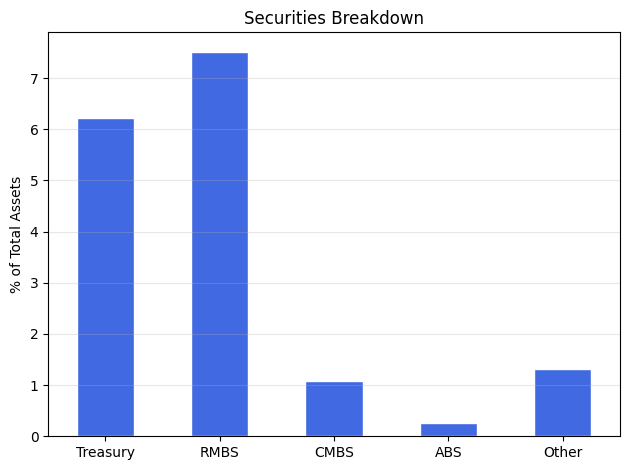

In [62]:
sec_cols = {
    'Treasury': 'security_treasury',
    'RMBS': 'security_rmbs',
    'CMBS': 'security_cmbs',
    'ABS': 'security_abs',
    'Other': 'security_other',
}

sec_pct = (pd.Series({l: panel[c].sum() for l, c in sec_cols.items() if c in panel.columns}) / panel['Total Asset'].sum() * 100).round(2)

print('Securities as % of total assets:')
print(sec_pct)

sec_pct.plot(kind='bar', color='royalblue', edgecolor='white')
plt.ylabel('% of Total Assets')
plt.title('Securities Breakdown')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Asset Composition by Bank Category

          Cash  Securities  Total Loan  Fed Funds Sold  Reverse Repo
Category                                                            
Small      8.2        19.1        67.5             0.9           0.0
Large      7.6        20.5        64.2             0.0           0.2
GSIB      12.8        23.1        41.8             0.0           5.3


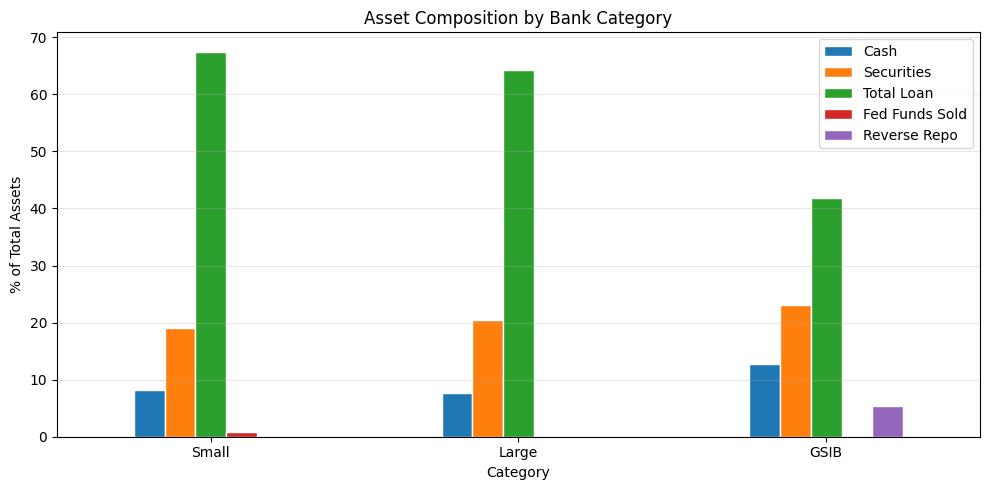

In [63]:
cat_order = ['Small', 'Large', 'GSIB']

rows = []
for cat in cat_order:
    sub = panel[panel['bank_category'] == cat]
    total = sub['Total Asset'].sum()
    row = {'Category': cat}
    for label, col in asset_cols.items():
        if col in panel.columns:
            row[label] = round(sub[col].sum() / total * 100, 1)
    rows.append(row)

cat_df = pd.DataFrame(rows).set_index('Category')
print(cat_df)

cat_df.plot(kind='bar', figsize=(10, 5), edgecolor='white')
plt.ylabel('% of Total Assets')
plt.title('Asset Composition by Bank Category')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.6 Missing Values

In [64]:
missing = panel.isna().mean().sort_values(ascending=False)
missing_nonzero = missing[missing > 0]
print(f'{len(missing_nonzero)} columns have missing values out of {len(panel.columns)}')
print()
print((missing_nonzero * 100).round(1).to_string())

2 columns have missing values out of 67

Foreign Deposit    98.7
Repo                0.6


## 5. Market Shocks (Yield-Derived)

In [65]:
print('Shape:', shocks.shape)
shocks.T.rename(columns={0: 'value'})

Shape: (1, 7)


,value
d_tsy_lt1y,3.2000
d_tsy_1_3y,2.7950
d_tsy_3_5y,2.2700
d_tsy_5_10y,2.0550
d_tsy_10_15y,1.9575
d_tsy_15plus,1.8880
rmbs_multiplier,1.2500


### 5.1 Shock Size Across Maturity Buckets

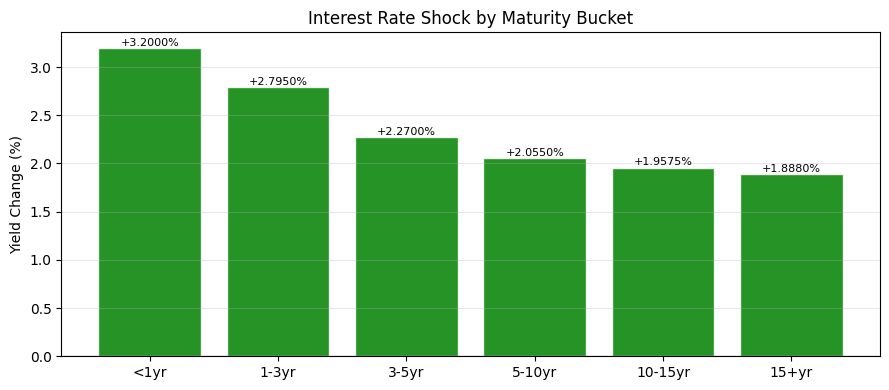

In [66]:
bucket_cols   = ['d_tsy_lt1y', 'd_tsy_1_3y', 'd_tsy_3_5y', 'd_tsy_5_10y', 'd_tsy_10_15y', 'd_tsy_15plus']
bucket_labels = ['<1yr', '1-3yr', '3-5yr', '5-10yr', '10-15yr', '15+yr']

shock_vals = shocks[bucket_cols].iloc[0].values
colors = ['green' if v >= 0 else 'red' for v in shock_vals]

plt.figure(figsize=(9, 4))
bars = plt.bar(bucket_labels, shock_vals, color=colors, edgecolor='white', alpha=0.85)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Yield Change (%)')
plt.title('Interest Rate Shock by Maturity Bucket')
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, shock_vals):
    plt.text(bar.get_x() + bar.get_width() / 2,
             val + (0.001 if val >= 0 else -0.002),
             f'{val:+.4f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 5.2 Yield Curve: Start vs End of Shock Window

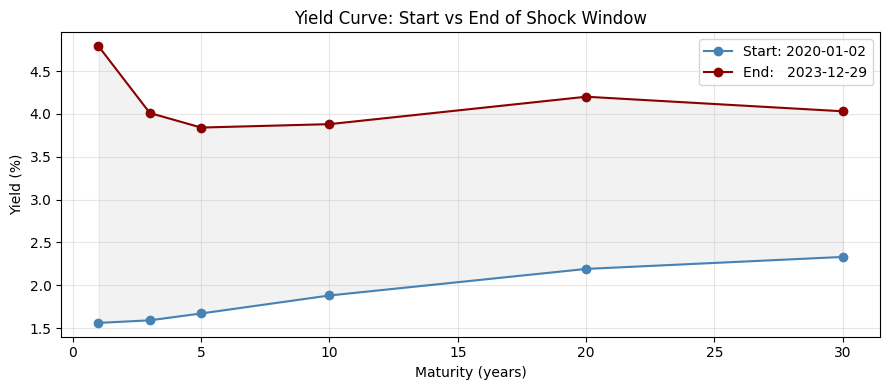


Yield changes (end - start):
   1yr  1.560% -> 4.790%  delta = +3.230%
   3yr  1.590% -> 4.010%  delta = +2.420%
   5yr  1.670% -> 3.840%  delta = +2.170%
  10yr  1.880% -> 3.880%  delta = +2.000%
  20yr  2.190% -> 4.200%  delta = +2.010%
  30yr  2.330% -> 4.030%  delta = +1.700%


In [67]:
treasury_sorted = treasury.sort_values('date')
start_row = treasury_sorted.iloc[(treasury_sorted['date'] - start_date).abs().argsort()[:1]].iloc[0]
end_row   = treasury_sorted.iloc[(treasury_sorted['date'] - end_date).abs().argsort()[:1]].iloc[0]

maturities   = [1, 3, 5, 10, 20, 30]
start_yields = [start_row[c] for c in yield_cols]
end_yields   = [end_row[c]   for c in yield_cols]

plt.figure(figsize=(9, 4))
plt.plot(maturities, start_yields, marker='o', label=f'Start: {start_row["date"].date()}', color='steelblue')
plt.plot(maturities, end_yields,   marker='o', label=f'End:   {end_row["date"].date()}',   color='darkred')
plt.fill_between(maturities, start_yields, end_yields, alpha=0.1, color='grey')
plt.xlabel('Maturity (years)')
plt.ylabel('Yield (%)')
plt.title('Yield Curve: Start vs End of Shock Window')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nYield changes (end - start):')
for col, mat, s, e in zip(yield_cols, maturities, start_yields, end_yields):
    print(f'  {mat:2d}yr  {s:.3f}% -> {e:.3f}%  delta = {e-s:+.3f}%')

### 5.3 Estimated Mark-to-Market Loss per Bank

In [68]:
bucket_durations = {
    'lt1y':   0.5,
    '1_3y':   2.0,
    '3_5y':   4.0,
    '5_10y':  7.5,
    '10_15y': 12.5,
    '15plus': 22.0,
}

rmbs_mult = shocks['rmbs_multiplier'].iloc[0]

loss_df = panel[['rssd_id_call', 'Total Asset', 'bank_category']].copy()
loss_df['total_loss'] = 0.0

for bucket, duration in bucket_durations.items():
    shock_val = shocks[f'd_tsy_{bucket}'].iloc[0] / 100
    tsy_col   = f'treasury_{bucket}'
    rmbs_col  = f'rmbs_{bucket}'
    if tsy_col in panel.columns:
        loss_df['total_loss'] += panel[tsy_col].fillna(0) * shock_val * duration
    if rmbs_col in panel.columns:
        loss_df['total_loss'] += panel[rmbs_col].fillna(0) * shock_val * duration * rmbs_mult

loss_df['loss_pct'] = (loss_df['total_loss'] / loss_df['Total Asset']) * 100

print('Aggregate loss ($T):', round(loss_df['total_loss'].sum() / 1e9, 2))
print('\nMean loss as % of assets by category:')
print(loss_df.groupby('bank_category')['loss_pct'].mean().round(3))

Aggregate loss ($T): 0.32

Mean loss as % of assets by category:
bank_category
GSIB     0.786
Large    0.115
Small    0.002
Name: loss_pct, dtype: float64


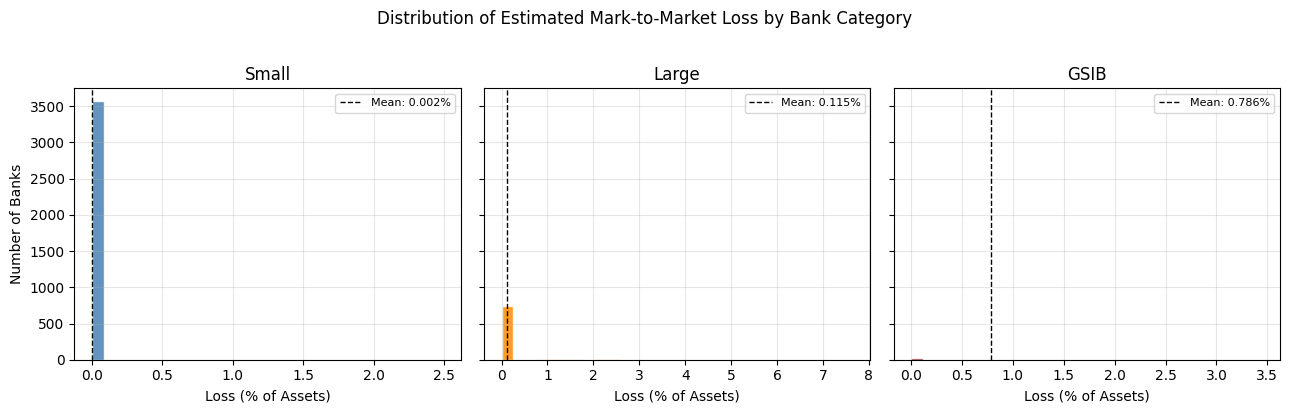

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, cat, color in zip(axes, ['Small', 'Large', 'GSIB'], ['steelblue', 'darkorange', 'darkred']):
    data = loss_df[loss_df['bank_category'] == cat]['loss_pct'].dropna()
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1, label=f'Mean: {data.mean():.3f}%')
    ax.set_title(cat)
    ax.set_xlabel('Loss (% of Assets)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Number of Banks')
plt.suptitle('Distribution of Estimated Mark-to-Market Loss by Bank Category', y=1.02)
plt.tight_layout()
plt.show()

In [70]:
top10 = loss_df.nlargest(10, 'loss_pct')[['rssd_id_call', 'bank_category', 'Total Asset', 'total_loss', 'loss_pct']]
top10['Total Asset ($B)'] = (top10['Total Asset'] / 1e6).round(2)
top10['Loss ($B)']        = (top10['total_loss'] / 1e6).round(2)
top10['Loss (% Assets)']  = top10['loss_pct'].round(3)
top10[['rssd_id_call', 'bank_category', 'Total Asset ($B)', 'Loss ($B)', 'Loss (% Assets)']]

,rssd_id_call,bank_category,Total Asset ($B),Loss ($B),Loss (% Assets)
4324,5278251,Large,10.43,0.80,7.652
3690,1893049,Large,27.02,1.53,5.672
3223,918918,Large,12.46,0.65,5.197
4031,3150447,Large,253.77,12.63,4.978
3321,940311,Large,59.77,2.75,4.604
3661,1456501,GSIB,253.35,8.74,3.452
2773,795968,Large,24.14,0.78,3.232
2153,619877,Large,107.99,3.18,2.941
3636,1225761,GSIB,9.01,0.24,2.636
1235,364270,Small,0.18,0.00,2.493


## 6. Table 1 — Bank Fragility Summary

In [71]:
import importlib.util

table_path = OUTPUT_DIR / 'table_1.csv'

if not table_path.exists():
    print('table_1.csv not found — generating now...')
    spec = importlib.util.spec_from_file_location(
        'make_table_1',
        Path('../scripts/make_table_1.py')
    )
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    mod.main()
    print('Done.')

table1 = pd.read_csv(table_path, index_col=0)
table1.index = table1.index.fillna('(std dev)')
table1

,All Banks,"Small\n(0, 1.384B)","Large (non-GSIB)\n[1.384B, )",GSIB
Aggregate Loss,28.2T,1.9B,11.9T,16.3T
Bank-Level Loss,6425.8M,0.5M,15144.0M,479402.3M
(std dev),"-117,533.50",-21.9,"-97,955.00","-1,171,901.10"
Share RMBS,19,27.5,21,12.1
(std dev),-18.4,-34.1,-17.9,-13.3
Share Treasury and Other,24,25,18.1,38.1
(std dev),-27.5,-21.1,-22,-35.6
Share Residential Mortgage,17,0,15.5,24.7
(std dev),-20.9,0,-15.5,-30.2
Share Other Loan,40,47.6,45.5,25.1


### 6.1 Aggregate Loss by Group

In [72]:
if table1 is not None:
    agg_loss_row = table1.loc['Aggregate Loss']
    print('Aggregate Loss by Group:')
    print(agg_loss_row.to_string())

Aggregate Loss by Group:
All Banks                       28.2T
Small\n(0, 1.384B)               1.9B
Large (non-GSIB)\n[1.384B, )    11.9T
GSIB                            16.3T


### 6.2 Loss/Asset % by Group

In [73]:
if table1 is not None:
    metric_rows = [
        'Aggregate Loss', 'Bank-Level Loss',
        'Share RMBS', 'Share Treasury and Other',
        'Share Residential Mortgage', 'Share Other Loan',
        'Loss/Asset', 'Uninsured Deposit/MM Asset', 'Number of Banks',
    ]
    # Include (std dev) rows that follow each metric
    full_rows = []
    for i, idx in enumerate(table1.index):
        if idx in metric_rows:
            full_rows.append(idx)
            if i + 1 < len(table1) and table1.index[i + 1] == '(std dev)':
                full_rows.append('(std dev)')

    print(table1.loc[full_rows].to_string())

                              All Banks Small\n(0, 1.384B) Large (non-GSIB)\n[1.384B, )           GSIB
Aggregate Loss                    28.2T               1.9B                        11.9T          16.3T
Bank-Level Loss                 6425.8M               0.5M                     15144.0M      479402.3M
(std dev)                   -117,533.50              -21.9                   -97,955.00  -1,171,901.10
(std dev)                         -18.4              -34.1                        -17.9          -13.3
(std dev)                         -27.5              -21.1                          -22          -35.6
(std dev)                         -20.9                  0                        -15.5          -30.2
(std dev)                         -27.6              -29.8                        -24.3          -30.1
(std dev)                         -20.1               -2.3                        -42.5          -68.6
(std dev)                         -93.6              -33.8               

### 6.3 Loss/Asset and Uninsured Deposit/MM Asset — Visual Comparison

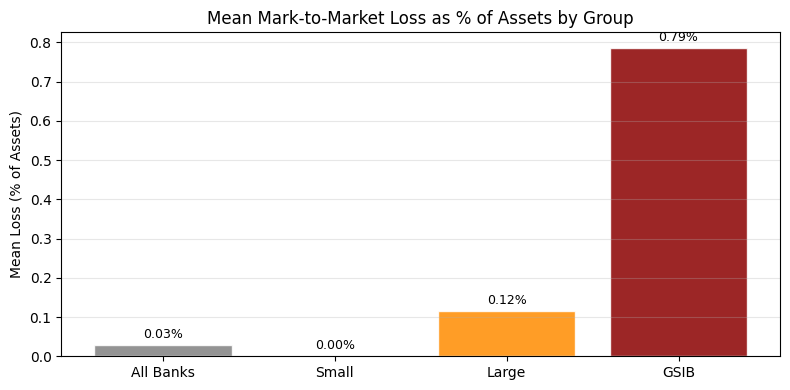

In [74]:
groups = ['All Banks', 'Small\n(0, 1.384B)', 'Large (non-GSIB)\n[1.384B, )', 'GSIB']
groups_present = [g for g in groups if g in loss_df['bank_category'].unique() or True]

# Recompute from loss_df for plotting
plot_groups = {
    'All Banks':  loss_df,
    'Small':      loss_df[loss_df['bank_category'] == 'Small'],
    'Large':      loss_df[loss_df['bank_category'] == 'Large'],
    'GSIB':       loss_df[loss_df['bank_category'] == 'GSIB'],
}

mean_loss = {k: v['loss_pct'].mean() for k, v in plot_groups.items()}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(mean_loss.keys(), mean_loss.values(),
              color=['grey', 'steelblue', 'darkorange', 'darkred'], edgecolor='white', alpha=0.85)
for bar, val in zip(bars, mean_loss.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Mean Loss (% of Assets)')
ax.set_title('Mean Mark-to-Market Loss as % of Assets by Group')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()